<a href="https://colab.research.google.com/github/Matheesha-w/SE4050-Lab8/blob/main/Gridworld.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The agent-environment interaction

In this exercise, you will implement the interaction of a reinforecment learning agent with its environment. We will use the gridworld environment from the second lecture. You will find a description of the environment below, along with two pieces of relevant material from the lectures: the agent-environment interface and the Q-learning algorithm.

1. Create an agent that chooses actions randomly with this environment.

2. Create an agent that uses Q-learning. You can use initial Q values of 0, a stochasticity parameter for the $\epsilon$-greedy policy function $\epsilon=0.05$, and a learning rate $\alpha = 0.1$. But feel free to experiment with other settings of these three parameters.

3. Plot the mean total reward obtained by the two agents through the episodes. This is called a **learning curve**. Run enough episodes for the Q-learning agent to converge to a near-optimal policy.


## The agent-environment interface

<img src="https://raw.githubusercontent.com/dkasthurirathna/dl/master/agent-environment.png" style="width: 500px;" align="left"/>

<br><br><br>

The interaction of the agent with its environments starts at decision stage $t=0$ with the observation of the current state $s_0$. (Notice that there is no reward at this initial stage.) The agent then chooses an action to execute at decision stage $t=1$. The environment responds by changing its state to $s_1$ and returning the numerical reward signal $r_1$.


## The environment: Navigation in a gridworld

<img src="https://raw.githubusercontent.com/dkasthurirathna/dl/master/gold.png" style="width: 250px;" align="left"/>

The agent has four possible actions in each state (grid square): west, north, south, and east. The actions are unreliable. They move the agent in the intended direction with probability 0.8, and with probability 0.2, they move the agent in a random other direction. It the direction of movement is blocked, the agent remains in the same grid square. The initial state of the agent is one of the five grid squares at the bottom, selected randomly. The grid squares with the gold and the bomb are **terminal states**. If the agent finds itself in one of these squares, the episode ends. Then a new episode begins with the agent at the initial state.

You will use a reinforcement learning algorithm to compute the best policy for finding the gold with as few steps as possible while avoiding the bomb. For this, we will use the following reward function: $-1$ for each navigation action, an additional $+10$ for finding the gold, and an additional $-10$ for hitting the bomb. For example, the immediate reward for transitioning into the square with the gold is $-1 + 10 = +9$. Do not use discounting (that is, set $\gamma=1$).

## Q-learning

![title](https://raw.githubusercontent.com/dkasthurirathna/dl/master/q.png)
From Sutton & Barto (1998), Reinforcement Learning.

In [ ]:
import numpy as np
import operator
import matplotlib.pyplot as plt
%matplotlib inline

# Classes for the Enviroment and the Agent

- The GridWorld class contains the environment
- The dimensions of the environment are defined
- Locations of all rewards are stored
- Functions for different methods written
    - `get_available_actions` returns possible actions
    - `agent_on_map` prints out current location of the agent on the grid (used for debugging)
    - `get_reward` returns the reward for an input position
    - `make_step` moves the agent in a specified direction

In [ ]:
class GridWorld:
    ## Initialise starting data
    def __init__(self, height=8, width=8):
        # Set information about the gridworld
        self.height = height
        self.width = width
        self.grid = np.zeros(( self.height, self.width)) - 1

        # Set random start location for the agent
        self.current_location = ( self.height // 2, np.random.randint(0, min(5, self.width)))

        # Set locations for the bomb and the gold
        self.bomb_location = (1, self.width // 2 - 1)
        self.gold_location = (0, self.width // 2 - 1)
        self.terminal_states = [ self.bomb_location, self.gold_location]

        # Set grid rewards for special cells
        self.grid[ self.bomb_location[0], self.bomb_location[1]] = -10
        self.grid[ self.gold_location[0], self.gold_location[1]] = 10

        # Set available actions
        self.actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']

    def reset(self):
        """Resets the environment keeping the same grid size"""
        self.__init__(self.height, self.width)

    ## Put methods here:
    def get_available_actions(self):
        """Returns possible actions"""
        return self.actions

    def agent_on_map(self):
        """Prints out current location of the agent on the grid (used for debugging)"""
        grid = np.zeros(( self.height, self.width))
        grid[ self.current_location[0], self.current_location[1]] = 1
        return grid

    def get_reward(self, new_location):
        """Returns the reward for an input position"""
        return self.grid[ new_location[0], new_location[1]]


    def make_step(self, action):
        """Moves the agent in the specified direction. If agent is at a border, agent stays still
        but takes negative reward. Function returns the reward for the move."""
        # Store previous location
        last_location = self.current_location

        # UP
        if action == 'UP':
            # If agent is at the top, stay still, collect reward
            if last_location[0] == 0:
                reward = self.get_reward(last_location)
            else:
                self.current_location = ( self.current_location[0] - 1, self.current_location[1])
                reward = self.get_reward(self.current_location)

        # DOWN
        elif action == 'DOWN':
            # If agent is at bottom, stay still, collect reward
            if last_location[0] == self.height - 1:
                reward = self.get_reward(last_location)
            else:
                self.current_location = ( self.current_location[0] + 1, self.current_location[1])
                reward = self.get_reward(self.current_location)

        # LEFT
        elif action == 'LEFT':
            # If agent is at the left, stay still, collect reward
            if last_location[1] == 0:
                reward = self.get_reward(last_location)
            else:
                self.current_location = ( self.current_location[0], self.current_location[1] - 1)
                reward = self.get_reward(self.current_location)

        # RIGHT
        elif action == 'RIGHT':
            # If agent is at the right, stay still, collect reward
            if last_location[1] == self.width - 1:
                reward = self.get_reward(last_location)
            else:
                self.current_location = ( self.current_location[0], self.current_location[1] + 1)
                reward = self.get_reward(self.current_location)

        return reward

    def check_state(self):
        """Check if the agent is in a terminal state (gold or bomb), if so return 'TERMINAL'"""
        if self.current_location in self.terminal_states:
            return 'TERMINAL'

In [ ]:
class RandomAgent():
    # Choose a random action
    def choose_action(self, available_actions):
        """Returns a random choice of the available actions"""
        return np.random.choice(available_actions)

In [ ]:
class Q_Agent():
    # Intialise
    def __init__(self, environment, epsilon=0.05, alpha=0.1, gamma=1):
        self.environment = environment
        self.q_table = dict() # Store all Q-values in dictionary of dictionaries
        for x in range(environment.height): # Loop through all possible grid spaces, create sub-dictionary for each
            for y in range(environment.width):
                self.q_table[(x,y)] = {'UP':0, 'DOWN':0, 'LEFT':0, 'RIGHT':0} # Populate sub-dictionary with zero values for possible moves

        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma

    def choose_action(self, available_actions):
        """Returns the optimal action from Q-Value table. If multiple optimal actions, chooses random choice.
        Will make an exploratory random action dependent on epsilon."""
        if np.random.uniform(0, 1) < self.epsilon:
            action = available_actions[np.random.randint(0, len(available_actions))]
        else:
            q_values_of_state = self.q_table[self.environment.current_location]
            maxValue = max(q_values_of_state.values())
            action = np.random.choice([k for k, v in q_values_of_state.items() if v == maxValue])
        return action

    def learn(self, old_state, reward, new_state, action):
        """Updates the Q-value table using Q-learning"""
        q_values_of_state = self.q_table[new_state]
        max_q_value_in_new_state = max(q_values_of_state.values())
        current_q_value = self.q_table[old_state][action]
        self.q_table[old_state][action] = (1 - self.alpha) * current_q_value + self.alpha * (reward + self.gamma * max_q_value_in_new_state)

In [ ]:
def play(environment, agent, trials=500, max_steps_per_episode=1000, learn=False):
    """The play function runs iterations and updates Q-values if desired."""
    reward_per_episode = [] # Initialise performance log

    for trial in range(trials): # Run trials
        cumulative_reward = 0 # Initialise values of each game
        step = 0
        game_over = False
        while step < max_steps_per_episode and game_over != True: # Run until max steps or until game is finished
            old_state = environment.current_location
            action = agent.choose_action(environment.actions)
            reward = environment.make_step(action)
            new_state = environment.current_location

            if learn == True: # Update Q-values if learning is specified
                agent.learn(old_state, reward, new_state, action)

            cumulative_reward += reward
            step += 1

            if environment.check_state() == 'TERMINAL': # If game is in terminal state, game over and start next trial
                environment.reset()
                game_over = True

        reward_per_episode.append(cumulative_reward) # Append reward for current trial to performance log

    return reward_per_episode # Return performance log

## Run Random Agent

- Random agent moves randomly and does not learn from it's actions.
- This gives a base performance to compare the Q-Learning agent to

In [ ]:
env = GridWorld()
agent = RandomAgent()

print("Current position of the agent =", env.current_location)
print(env.agent_on_map())
available_actions = env.get_available_actions()
print("Available_actions =", available_actions)
chosen_action = agent.choose_action(available_actions)
print("Randomly chosen action =", chosen_action)
reward = env.make_step(chosen_action)
print("Reward obtained =", reward)
print("Current position of the agent =", env.current_location)
print(env.agent_on_map())

Current position of the agent = (4, 0)
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
Available_actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
Randomly chosen action = LEFT
Reward obtained = -1.0
Current position of the agent = (4, 0)
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


- Here the random agent is ran for 500 trials
- Performance is obviously inconsistent and not optimal

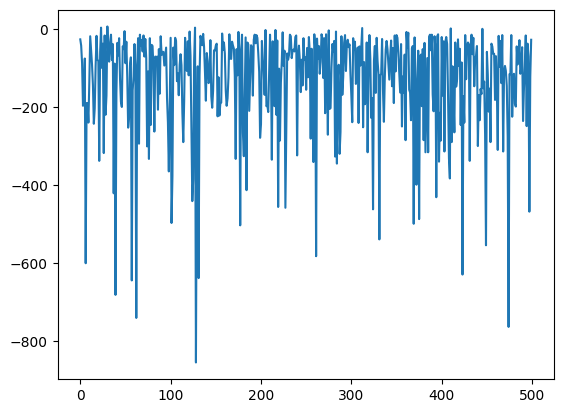

In [ ]:
# Initialize environment and agent
environment = GridWorld()
random_agent = RandomAgent()

reward_per_episode = play(environment, random_agent, trials=500)

# Simple learning curve
plt.plot(reward_per_episode)

## Q-Agent

- Here the Q-Learning agent is ran for 500 trials again
- Performance is plotted
- Performance increases greatly

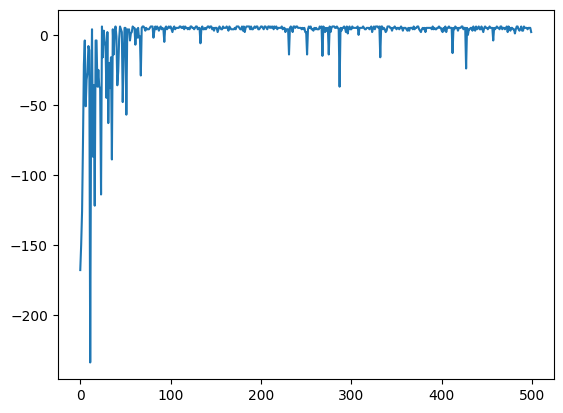

In [ ]:
environment = GridWorld()
agentQ = Q_Agent(environment)

# Note the learn=True argument!
reward_per_episode = play(environment, agentQ, trials=500, learn=True)

# Simple learning curve
plt.plot(reward_per_episode)

Print the final Q-value table with nice formatting.

In [ ]:
def pretty(d, indent=0):
    for key, value in d.items():
        print('\t' * indent + str(key))
        if isinstance(value, dict):
            pretty(value, indent+1)
        else:
            print('\t' * (indent+1) + str(value))


pretty(agentQ.q_table)

(0, 0)
	UP
		-0.30000000000000004
	DOWN
		-0.31909000000000004
	LEFT
		-0.30000000000000004
	RIGHT
		-0.257149
(0, 1)
	UP
		-0.1
	DOWN
		-0.2
	LEFT
		-0.1
	RIGHT
		6.043567048346153
(0, 2)
	UP
		3.6324458978690575
	DOWN
		3.73466220848664
	LEFT
		1.8932585586282555
	RIGHT
		9.999999999999995
(0, 3)
	UP
		0
	DOWN
		0
	LEFT
		0
	RIGHT
		0
(0, 4)
	UP
		1.707042598049519
	DOWN
		0
	LEFT
		9.999444667132748
	RIGHT
		0.3112368349413537
(0, 5)
	UP
		-0.1
	DOWN
		-0.1
	LEFT
		3.9240382450783176
	RIGHT
		-0.1
(0, 6)
	UP
		-0.30000000000000004
	DOWN
		-0.30000000000000004
	LEFT
		-0.16113620930328995
	RIGHT
		-0.32620000000000005
(0, 7)
	UP
		-0.39000000000000007
	DOWN
		-0.4271000000000001
	LEFT
		-0.4726743428900001
	RIGHT
		-0.4000000000000001
(1, 0)
	UP
		-0.45561
	DOWN
		-0.5828998254172444
	LEFT
		-0.5000000000000001
	RIGHT
		-0.4696378649419363
(1, 1)
	UP
		-0.28900000000000003
	DOWN
		-0.33290652880000005
	LEFT
		-0.31620000000000004
	RIGHT
		2.7460365787308856
(1, 2)
	UP
		8.99999999999

## Learning curve: Random agent vs Q-Learning agent

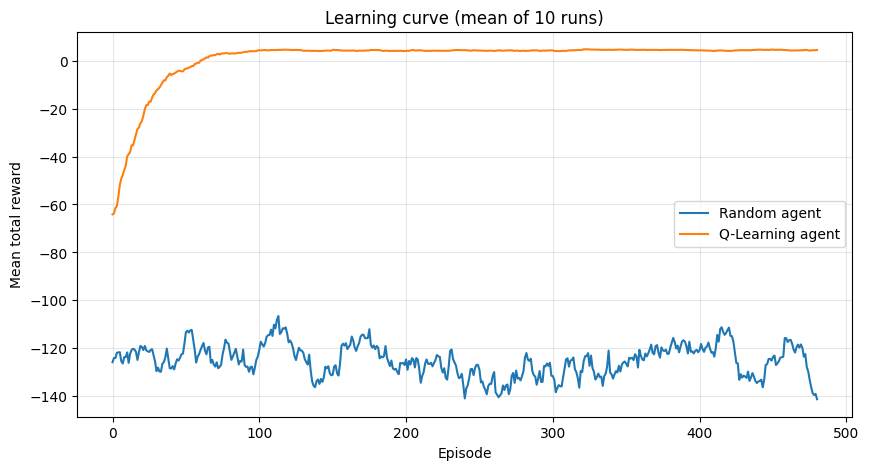

In [ ]:
def moving_average(x, w=20):
    return np.convolve(x, np.ones(w) / w, mode='valid')

n_runs, trials = 10, 500
rand_curves, q_curves = [], []
for run in range(n_runs):
    env_r = GridWorld()
    rand_curves.append(play(env_r, RandomAgent(), trials=trials))
    env_q = GridWorld()
    q_curves.append(play(env_q, Q_Agent(env_q), trials=trials, learn=True))

plt.figure(figsize=(10, 5))
plt.plot(moving_average(np.mean(rand_curves, axis=0)), label='Random agent')
plt.plot(moving_average(np.mean(q_curves, axis=0)), label='Q-Learning agent')
plt.xlabel('Episode'); plt.ylabel('Mean total reward')
plt.title('Learning curve (mean of {} runs)'.format(n_runs))
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Increasing the grid size

Training a Q-learning agent on bigger grids and recording the execution time and when it converges. Convergence episode is taken as the first episode where the 50-episode moving average reaches close to the final reward (mean of last 100 episodes).

In [ ]:
import time

def play_timed(environment, agent, trials=500, max_steps_per_episode=1000):
    reward_per_episode, cum_time, steps_per_episode = [], [], []
    t0 = time.perf_counter()
    for trial in range(trials):
        cumulative_reward, step, game_over = 0, 0, False
        while step < max_steps_per_episode and not game_over:
            old_state = environment.current_location
            action = agent.choose_action(environment.actions)
            reward = environment.make_step(action)
            agent.learn(old_state, reward, environment.current_location, action)
            cumulative_reward += reward
            step += 1
            if environment.check_state() == 'TERMINAL':
                environment.reset()
                game_over = True
        if not game_over:
            environment.reset()
        reward_per_episode.append(cumulative_reward)
        steps_per_episode.append(step)
        cum_time.append(time.perf_counter() - t0)
    return np.array(reward_per_episode), np.array(cum_time), np.array(steps_per_episode)

def convergence_episode(rewards, window=50):
    ma = moving_average(rewards, window)
    final = np.mean(rewards[-100:])
    tol = max(1.0, 0.05 * abs(final))
    idx = np.where(ma >= final - tol)[0]
    return int(idx[0] + window - 1) if len(idx) else len(rewards) - 1

grid_sizes = [8, 16, 32, 64]
trials = 1000
size_results, size_curves = [], {}
np.random.seed(0)
for n in grid_sizes:
    env_n = GridWorld(height=n, width=n)
    agent_n = Q_Agent(env_n)
    rewards, cum_time, steps = play_timed(env_n, agent_n, trials=trials, max_steps_per_episode=5000)
    ep = convergence_episode(rewards)
    size_curves[n] = rewards
    size_results.append({'Grid size': '{}x{}'.format(n, n), 'States': n*n,
                         'Total time (s)': round(cum_time[-1], 2),
                         'Total steps': int(steps.sum()),
                         'Convergence episode': ep,
                         'Time to converge (s)': round(cum_time[ep], 2),
                         'Final mean reward': round(np.mean(rewards[-100:]), 2)})
    print('Grid {}x{}: total time {:.2f}s, converged at episode {}, time to converge {:.2f}s'.format(
        n, n, cum_time[-1], ep, cum_time[ep]))

Grid 8x8: total time 0.26s, converged at episode 142, time to converge 0.11s
Grid 16x16: total time 1.24s, converged at episode 397, time to converge 1.03s
Grid 32x32: total time 8.92s, converged at episode 830, time to converge 8.43s
Grid 64x64: total time 42.37s, converged at episode 732, time to converge 36.50s


,Grid size,States,Total time (s),Total steps,Convergence episode,Time to converge (s),Final mean reward
0,8x8,64,0.26,8723,142,0.11,4.61
1,16x16,256,1.24,41302,397,1.03,-3.04
2,32x32,1024,8.92,315964,830,8.43,-111.06
3,64x64,4096,42.37,1601591,732,36.50,-810.35


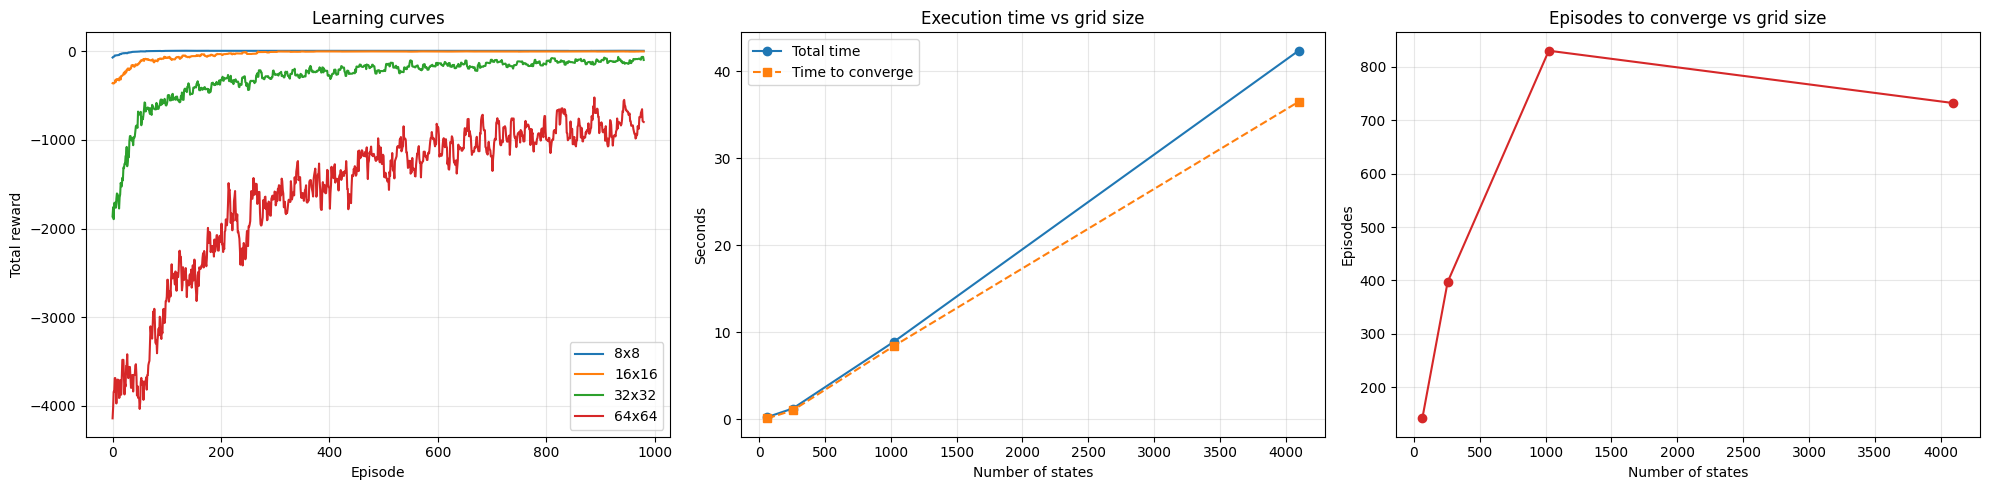

In [ ]:
import pandas as pd
size_df = pd.DataFrame(size_results)
display(size_df)

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for n in grid_sizes:
    axs[0].plot(moving_average(size_curves[n], 20), label='{}x{}'.format(n, n))
axs[0].set_xlabel('Episode'); axs[0].set_ylabel('Total reward')
axs[0].set_title('Learning curves'); axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(size_df['States'], size_df['Total time (s)'], 'o-', label='Total time')
axs[1].plot(size_df['States'], size_df['Time to converge (s)'], 's--', label='Time to converge')
axs[1].set_xlabel('Number of states'); axs[1].set_ylabel('Seconds'); axs[1].set_title('Execution time vs grid size')
axs[1].legend(); axs[1].grid(alpha=0.3)

axs[2].plot(size_df['States'], size_df['Convergence episode'], 'o-', color='tab:red')
axs[2].set_xlabel('Number of states'); axs[2].set_ylabel('Episodes'); axs[2].set_title('Episodes to converge vs grid size')
axs[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

When the grid size increases, the number of states increases a lot and the gold is further away from the start. The agent takes many more steps in the early episodes before finding the gold, so the execution time goes up quickly (0.26s for 8x8 up to about 42s for 64x64, and the total steps went from about 8.7 thousand to 1.6 million).

The number of episodes needed to converge also increased from 142 (8x8) to 397 (16x16) and 830 (32x32). For 64x64 the agent did not fully converge within 1000 episodes. The learning curve is still going up and the final reward (-810) is far from the best possible, so the convergence episode shown for 64x64 is not reliable. It would need many more episodes. This shows that tabular Q-learning becomes slow for large state spaces.